In [20]:
# ============================================================
# STEP 1: Load the raw NHS MHSDS time series data
# ============================================================
# This CSV contains monthly mental health service statistics 
# reported by NHS providers/trusts across England.
import pandas as pd

df = pd.read_csv("../data/raw/MHSDS Time_Series_data_Apr2025_Mar_Perf_2026_v2.csv")

# Check the size of the dataset and see what columns we have
print(df.shape)
print(df.columns.tolist())
df.head()


(644400, 11)
['REPORTING_PERIOD_START', 'REPORTING_PERIOD_END', 'STATUS', 'BREAKDOWN', 'PRIMARY_LEVEL', 'PRIMARY_LEVEL_DESCRIPTION', 'SECONDARY_LEVEL', 'SECONDARY_LEVEL_DESCRIPTION', 'MEASURE_ID', 'MEASURE_NAME', 'MEASURE_VALUE']


,REPORTING_PERIOD_START,REPORTING_PERIOD_END,STATUS,BREAKDOWN,PRIMARY_LEVEL,PRIMARY_LEVEL_DESCRIPTION,SECONDARY_LEVEL,SECONDARY_LEVEL_DESCRIPTION,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE
0,01/04/2025,30/04/2025,Performance,Sub ICB - GP Practice or Residence,00L,NHS NORTH EAST AND NORTH CUMBRIA ICB - 00L,NONE,NONE,MHS24a,Under 16 bed days on adult wards in reporting ...,*
1,01/04/2025,30/04/2025,Performance,Sub ICB - GP Practice or Residence,00L,NHS NORTH EAST AND NORTH CUMBRIA ICB - 00L,NONE,NONE,MHS24b,Age 16 bed days on adult wards in reporting pe...,*
2,01/04/2025,30/04/2025,Performance,Sub ICB - GP Practice or Residence,00L,NHS NORTH EAST AND NORTH CUMBRIA ICB - 00L,NONE,NONE,MHS24c,Age 17 bed days on adult wards in reporting pe...,*
3,01/04/2025,30/04/2025,Performance,Sub ICB - GP Practice or Residence,00L,NHS NORTH EAST AND NORTH CUMBRIA ICB - 00L,NONE,NONE,MHS29,Contacts in RP,15330
4,01/04/2025,30/04/2025,Performance,Sub ICB - GP Practice or Residence,00L,NHS NORTH EAST AND NORTH CUMBRIA ICB - 00L,NONE,NONE,MHS69,"The number of children and young people, regar...",705


In [21]:
# ============================================================
# STEP 2: Search for crisis/emergency-related measures
# ============================================================
# The dataset contains 122 different measures. We only want the 
# ones relevant to mental health crisis demand, so we search 
# measure names for relevant keywords.
df['MEASURE_NAME'].unique()
crisis_keywords = ['A&E', 'crisis', 'liaison', 'detain', 'Mental Health Act', 'admission', 'emergency']

for keyword in crisis_keywords:
    matches = [m for m in df['MEASURE_NAME'].unique() if keyword.lower() in m.lower()]
    if matches:
        print(f"\n--- Matches for '{keyword}' ---")
        for m in matches:
            print(m)

for keyword in ['Mental Health Act', 'admission', 'detain']:
    matches = [m for m in df['MEASURE_NAME'].unique() if keyword.lower() in m.lower()]
    print(f"\n--- '{keyword}' ---")
    for m in matches:
        print(m)
        


--- Matches for 'A&E' ---
New referrals to liaison psychiatry teams from A&E in the reporting period
New referrals to liaison psychiatry teams from A&E in the reporting period, Aged 18 and over
New referrals to liaison psychiatry teams from A&E in the reporting period, Aged under 18
New referrals to liaison psychiatry teams from A&E in the reporting period with first face to face contact
New referrals to liaison psychiatry teams from A&E in the reporting period with first face to face contact, Aged 18 and over
New referrals to liaison psychiatry teams from A&E in the reporting period with first face to face contact, Aged under 18
New referrals to liaison psychiatry teams from A&E in the reporting period with first face to face contact within 1 hour
New referrals to liaison psychiatry teams from A&E in the reporting period with first face to face contact within 1 hour, Aged 18 and over
New referrals to liaison psychiatry teams from A&E in the reporting period with first face to face co

In [22]:
# ============================================================
# STEP 3: Filter the full dataset down to our 3 chosen measures
# ============================================================
# These three measures best represent mental health crisis demand:
# - Emergency referrals to Crisis Care teams (our main target)
# - Very Urgent referrals to Crisis Care teams
# - Referrals to liaison psychiatry from A&E
target_measures = [
    'New Emergency Referrals to Crisis Care teams in the reporting period',
    'New Very Urgent Referrals to Crisis Care teams in the reporting period',
    'New referrals to liaison psychiatry teams from A&E in the reporting period',
]

df_crisis = df[df['MEASURE_NAME'].isin(target_measures)]
print(df_crisis.shape)
df_crisis.head(10)

(18447, 11)


,REPORTING_PERIOD_START,REPORTING_PERIOD_END,STATUS,BREAKDOWN,PRIMARY_LEVEL,PRIMARY_LEVEL_DESCRIPTION,SECONDARY_LEVEL,SECONDARY_LEVEL_DESCRIPTION,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE
3963,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99A,NHS CHESHIRE AND MERSEYSIDE ICB - 99A,NONE,NONE,PLS121,New referrals to liaison psychiatry teams from...,465
3972,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99C,NHS NORTH EAST AND NORTH CUMBRIA ICB - 99C,NONE,NONE,CCR117,New Very Urgent Referrals to Crisis Care teams...,*
3984,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99C,NHS NORTH EAST AND NORTH CUMBRIA ICB - 99C,NONE,NONE,CCR70,New Emergency Referrals to Crisis Care teams i...,*
3993,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99C,NHS NORTH EAST AND NORTH CUMBRIA ICB - 99C,NONE,NONE,PLS121,New referrals to liaison psychiatry teams from...,120
4002,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99E,NHS MID AND SOUTH ESSEX ICB - 99E,NONE,NONE,CCR117,New Very Urgent Referrals to Crisis Care teams...,*
4014,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99E,NHS MID AND SOUTH ESSEX ICB - 99E,NONE,NONE,CCR70,New Emergency Referrals to Crisis Care teams i...,*
4023,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99E,NHS MID AND SOUTH ESSEX ICB - 99E,NONE,NONE,PLS121,New referrals to liaison psychiatry teams from...,30
4032,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99F,NHS MID AND SOUTH ESSEX ICB - 99F,NONE,NONE,CCR117,New Very Urgent Referrals to Crisis Care teams...,*
4044,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99F,NHS MID AND SOUTH ESSEX ICB - 99F,NONE,NONE,CCR70,New Emergency Referrals to Crisis Care teams i...,*
4053,01/04/2025,30/04/2025,Performance,Sub ICB of GP Practice or Residence,99F,NHS MID AND SOUTH ESSEX ICB - 99F,NONE,NONE,PLS121,New referrals to liaison psychiatry teams from...,*


In [23]:
# ============================================================
# STEP 4: Pivot from "long" to "wide" format
# ============================================================
# Currently each row is ONE measure for ONE provider for ONE month.
# We want ONE row per provider per month, with each measure as 
# its own column — this is the format needed for modeling.
df_pivot = df_crisis.pivot_table(
    index=['REPORTING_PERIOD_START', 'PRIMARY_LEVEL_DESCRIPTION'],
    columns='MEASURE_NAME',
    values='MEASURE_VALUE',
    aggfunc='first'
).reset_index()

print(df_pivot.shape)
df_pivot.head(10)

(6149, 5)


MEASURE_NAME,REPORTING_PERIOD_START,PRIMARY_LEVEL_DESCRIPTION,New Emergency Referrals to Crisis Care teams in the reporting period,New Very Urgent Referrals to Crisis Care teams in the reporting period,New referrals to liaison psychiatry teams from A&E in the reporting period
0,01/01/2026,1POINT (NORTH WEST),*,*,*
1,01/01/2026,2BU SOMERSET,*,*,*
2,01/01/2026,42ND STREET,*,*,*
3,01/01/2026,ABBI CLINIC,*,*,*
4,01/01/2026,ABL HEALTH,*,*,*
5,01/01/2026,ABL HEALTH - SWINDON,*,*,*
6,01/01/2026,ACCESS COMMUNITY TRUST,*,*,*
7,01/01/2026,ACHIEVING FOR CHILDREN - RICHMOND AND KINGSTON,*,*,*
8,01/01/2026,ACTION FOR CHILDREN - DERBY CC EHWS,*,*,*
9,01/01/2026,ACTIVE CARE GROUP,*,*,*


In [24]:
print(df_pivot.isna().sum())
df_pivot.describe()

MEASURE_NAME
REPORTING_PERIOD_START                                                        0
PRIMARY_LEVEL_DESCRIPTION                                                     0
New Emergency Referrals to Crisis Care teams in the reporting period          0
New Very Urgent Referrals to Crisis Care teams in the reporting period        0
New referrals to liaison psychiatry teams from A&E in the reporting period    0
dtype: int64


MEASURE_NAME,REPORTING_PERIOD_START,PRIMARY_LEVEL_DESCRIPTION,New Emergency Referrals to Crisis Care teams in the reporting period,New Very Urgent Referrals to Crisis Care teams in the reporting period,New referrals to liaison psychiatry teams from A&E in the reporting period
count,6149,6149,6149,6149,6149
unique,12,621,98,153,302
top,01/02/2026,ABL HEALTH,*,*,*
freq,530,12,5048,4870,4281


In [25]:
# ============================================================
# STEP 5: Clean the data — convert text values to real numbers
# ============================================================
# NHS data uses '*' to mask small counts (usually under 5) for 
# patient privacy. We treat these as missing (NaN) rather than 
# guessing a number, since we don't know the true value.
measure_cols = [
    'New Emergency Referrals to Crisis Care teams in the reporting period',
    'New Very Urgent Referrals to Crisis Care teams in the reporting period',
    'New referrals to liaison psychiatry teams from A&E in the reporting period',
]

for col in measure_cols:
    df_pivot[col] = df_pivot[col].replace('*', pd.NA)  # mask suppressed values
    df_pivot[col] = pd.to_numeric(df_pivot[col], errors='coerce')  # convert text to numbers

print(df_pivot[measure_cols].isna().sum())
df_pivot[measure_cols].describe()
    

MEASURE_NAME
New Emergency Referrals to Crisis Care teams in the reporting period          5048
New Very Urgent Referrals to Crisis Care teams in the reporting period        4870
New referrals to liaison psychiatry teams from A&E in the reporting period    4281
dtype: int64


MEASURE_NAME,New Emergency Referrals to Crisis Care teams in the reporting period,New Very Urgent Referrals to Crisis Care teams in the reporting period,New referrals to liaison psychiatry teams from A&E in the reporting period
count,1101.000000,1279.000000,1868.000000
mean,92.427793,204.777170,601.180407
std,310.978528,768.479696,2491.827466
min,5.000000,5.000000,5.000000
25%,10.000000,15.000000,140.000000
50%,20.000000,45.000000,270.000000
75%,75.000000,115.000000,571.250000
max,3277.000000,7976.000000,34014.000000


In [26]:
# ============================================================
# STEP 6: Check data reliability per provider
# ============================================================
# Not all providers report every month. We check how many valid 
# (non-missing) months each provider has for our main target 
# measure, since a provider with only 1-2 months isn't useful 
# for spotting trends.
target_col = 'New Emergency Referrals to Crisis Care teams in the reporting period'

provider_counts = df_pivot.groupby('PRIMARY_LEVEL_DESCRIPTION')[target_col].apply(lambda x: x.notna().sum())
provider_counts = provider_counts.sort_values(ascending=False)

print(provider_counts.head(30))
print(f"\nProviders with at least 6 months of data: {(provider_counts >= 6).sum()}")
print(f"Providers with at least 3 months of data: {(provider_counts >= 3).sum()}")
print(f"Total unique providers: {len(provider_counts)}")

PRIMARY_LEVEL_DESCRIPTION
NAVIGO HEALTH AND SOCIAL CARE CIC                                  12
NHS GREATER MANCHESTER ICB - 14L                                   12
NHS HERTFORDSHIRE AND WEST ESSEX ICB - 07H                         12
ROTHERHAM DONCASTER AND SOUTH HUMBER NHS FOUNDATION TRUST          12
LIVEWELL SOUTHWEST                                                 12
EAST LONDON NHS FOUNDATION TRUST                                   12
NHS HEREFORDSHIRE AND WORCESTERSHIRE ICB - 18C                     12
SOUTH LONDON AND MAUDSLEY NHS FOUNDATION TRUST                     12
TEES, ESK AND WEAR VALLEYS NHS FOUNDATION TRUST                    12
NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES ICB - M1J4Y              12
BIRMINGHAM AND SOLIHULL MENTAL HEALTH NHS FOUNDATION TRUST         12
NHS CHESHIRE AND MERSEYSIDE ICB - 01J                              12
NHS CHESHIRE AND MERSEYSIDE ICB - 01T                              12
HEREFORDSHIRE AND WORCESTERSHIRE HEALTH AND CARE NHS TRUST      

In [27]:
# ============================================================
# STEP 7: Filter to reliable, well-reporting providers only
# ============================================================
# We only keep providers with at least 6 months of valid data, 
# since these give us enough history to build meaningful trends.
reliable_providers = provider_counts[provider_counts >= 6].index
df_model = df_pivot[df_pivot['PRIMARY_LEVEL_DESCRIPTION'].isin(reliable_providers)].copy()

print(df_model.shape)
df_model[measure_cols].describe()

(1178, 5)


MEASURE_NAME,New Emergency Referrals to Crisis Care teams in the reporting period,New Very Urgent Referrals to Crisis Care teams in the reporting period,New referrals to liaison psychiatry teams from A&E in the reporting period
count,1033.000000,835.000000,1168.000000
mean,96.082285,237.778443,770.869007
std,319.588874,937.194430,3129.533991
min,5.000000,5.000000,10.000000
25%,10.000000,15.000000,175.000000
50%,25.000000,40.000000,307.500000
75%,80.000000,105.000000,665.000000
max,3277.000000,7976.000000,34014.000000


In [28]:
# ============================================================
# STEP 8: Convert dates properly and sort chronologically
# ============================================================
# Dates were stored as text, which sorts incorrectly (e.g. "01" 
# before "12" regardless of year). Converting to real dates fixes 
# this, and sorting by provider + date puts each provider's months 
# in correct time order — essential before building trend features.
df_model['REPORTING_PERIOD_START'] = pd.to_datetime(df_model['REPORTING_PERIOD_START'], dayfirst=True)

df_model = df_model.sort_values(['PRIMARY_LEVEL_DESCRIPTION', 'REPORTING_PERIOD_START']).reset_index(drop=True)

print(df_model['REPORTING_PERIOD_START'].min())
print(df_model['REPORTING_PERIOD_START'].max())
print(df_model['REPORTING_PERIOD_START'].nunique())
df_model.head(15)

2025-04-01 00:00:00
2026-03-01 00:00:00
12


MEASURE_NAME,REPORTING_PERIOD_START,PRIMARY_LEVEL_DESCRIPTION,New Emergency Referrals to Crisis Care teams in the reporting period,New Very Urgent Referrals to Crisis Care teams in the reporting period,New referrals to liaison psychiatry teams from A&E in the reporting period
0,2025-04-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,15.0,NaN,645.0
1,2025-05-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,30.0,NaN,640.0
2,2025-06-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,10.0,NaN,640.0
3,2025-07-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,25.0,NaN,660.0
4,2025-08-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,25.0,NaN,645.0
5,2025-09-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,20.0,NaN,675.0
6,2025-10-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,15.0,NaN,600.0
7,2025-11-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,40.0,NaN,585.0
8,2025-12-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,40.0,NaN,585.0
9,2026-01-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,25.0,NaN,640.0


In [29]:
# ============================================================
# STEP 9: Create a "last month's value" feature
# ============================================================
# A key predictor for crisis demand is recent history: services 
# that were busy last month tend to stay busy. shift(1) copies 
# each provider's PREVIOUS month's value into a new column, 
# aligned with the current month's row.
df_model['emergency_referrals_last_month'] = (
    df_model.groupby('PRIMARY_LEVEL_DESCRIPTION')['New Emergency Referrals to Crisis Care teams in the reporting period']
    .shift(1)
)

df_model[['PRIMARY_LEVEL_DESCRIPTION', 'REPORTING_PERIOD_START', 
           'New Emergency Referrals to Crisis Care teams in the reporting period', 
           'emergency_referrals_last_month']].head(10)

MEASURE_NAME,PRIMARY_LEVEL_DESCRIPTION,REPORTING_PERIOD_START,New Emergency Referrals to Crisis Care teams in the reporting period,emergency_referrals_last_month
0,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-04-01,15.0,NaN
1,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-05-01,30.0,15.0
2,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-06-01,10.0,30.0
3,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-07-01,25.0,10.0
4,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-08-01,25.0,25.0
5,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-09-01,20.0,25.0
6,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-10-01,15.0,20.0
7,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-11-01,40.0,15.0
8,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-12-01,40.0,40.0
9,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2026-01-01,25.0,40.0


In [30]:
# ============================================================
#STEP 10- FEATURE ENGINEERING: Rolling average of past 3 months
# ============================================================
# Why: a single previous month's value can be noisy (e.g. one 
# unusually quiet or busy month). Averaging the last 3 months 
# gives the model a more stable signal of the recent trend.
#
# shift(1) first moves everything down by 1 month, so we're only 
# using PAST data (never today's own value) to avoid "leaking" 
# the answer into the prediction.

df_model['emergency_referrals_3mo_avg'] = (
    df_model.groupby('PRIMARY_LEVEL_DESCRIPTION')['New Emergency Referrals to Crisis Care teams in the reporting period']
    .shift(1)                      # look only at past months
    .rolling(window=3)             # take a 3-month window
    .mean()                        # average them
)

# Quick check: view a sample provider's data with both new features side by side
df_model[[
    'PRIMARY_LEVEL_DESCRIPTION', 
    'REPORTING_PERIOD_START', 
    'New Emergency Referrals to Crisis Care teams in the reporting period', 
    'emergency_referrals_last_month',
    'emergency_referrals_3mo_avg'
]].head(10)

MEASURE_NAME,PRIMARY_LEVEL_DESCRIPTION,REPORTING_PERIOD_START,New Emergency Referrals to Crisis Care teams in the reporting period,emergency_referrals_last_month,emergency_referrals_3mo_avg
0,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-04-01,15.0,NaN,NaN
1,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-05-01,30.0,15.0,NaN
2,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-06-01,10.0,30.0,NaN
3,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-07-01,25.0,10.0,18.333333
4,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-08-01,25.0,25.0,21.666667
5,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-09-01,20.0,25.0,20.000000
6,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-10-01,15.0,20.0,23.333333
7,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-11-01,40.0,15.0,20.000000
8,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2025-12-01,40.0,40.0,25.000000
9,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,2026-01-01,25.0,40.0,31.666667


In [31]:
# ============================================================
# STEP 11: Add a seasonality feature and check missing values
# ============================================================
# Crisis demand often varies by time of year (e.g. winter pressures, 
# holiday periods). We extract the month number so the model can 
# learn any seasonal pattern.
df_model['month'] = df_model['REPORTING_PERIOD_START'].dt.month

# Check how many rows now have missing values in our new features.
# These come from the first 1-2 months of each provider's history, 
# where there isn't enough past data yet to calculate a lag or average.
print(df_model[['emergency_referrals_last_month', 'emergency_referrals_3mo_avg']].isna().sum())
print(f"\nTotal rows: {len(df_model)}")

MEASURE_NAME
emergency_referrals_last_month    224
emergency_referrals_3mo_avg       473
dtype: int64

Total rows: 1178


In [32]:
# ============================================================
# STEP 12: Remove rows with missing lag/average features
# ============================================================
# Models can't handle missing values in their input features. 
# These missing rows are simply the "start" of each provider's 
# timeline, before enough history existed to calculate a lag or 
# average — so dropping them is safe and expected, not a data quality issue.
df_model_clean = df_model.dropna(subset=['emergency_referrals_last_month', 'emergency_referrals_3mo_avg']).copy()

print(f"Rows before: {len(df_model)}")
print(f"Rows after: {len(df_model_clean)}")
df_model_clean.head(10)

Rows before: 1178
Rows after: 705


MEASURE_NAME,REPORTING_PERIOD_START,PRIMARY_LEVEL_DESCRIPTION,New Emergency Referrals to Crisis Care teams in the reporting period,New Very Urgent Referrals to Crisis Care teams in the reporting period,New referrals to liaison psychiatry teams from A&E in the reporting period,emergency_referrals_last_month,emergency_referrals_3mo_avg,month
3,2025-07-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,25.0,NaN,660.0,10.0,18.333333,7
4,2025-08-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,25.0,NaN,645.0,25.0,21.666667,8
5,2025-09-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,20.0,NaN,675.0,25.0,20.000000,9
6,2025-10-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,15.0,NaN,600.0,20.0,23.333333,10
7,2025-11-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,40.0,NaN,585.0,15.0,20.000000,11
8,2025-12-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,40.0,NaN,585.0,40.0,25.000000,12
9,2026-01-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,25.0,NaN,640.0,40.0,31.666667,1
10,2026-02-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,25.0,NaN,565.0,25.0,35.000000,2
11,2026-03-01,AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP N...,25.0,NaN,670.0,25.0,30.000000,3
15,2025-07-01,BERKSHIRE HEALTHCARE NHS FOUNDATION TRUST,10.0,55.0,305.0,10.0,15.000000,7


In [33]:
# ============================================================
# STEP 13: Define our target and feature set for modeling
# ============================================================
# Target: what we want to predict — this month's Emergency Referrals
# Features: information available BEFORE this month that might help 
# predict it (past values + seasonality)

target = 'New Emergency Referrals to Crisis Care teams in the reporting period'

features = [
    'emergency_referrals_last_month',
    'emergency_referrals_3mo_avg',
    'month'
]

X = df_model_clean[features]  # inputs the model will learn from
y = df_model_clean[target]    # what the model tries to predict

print(X.shape)
print(y.shape)
X.head()

(705, 3)
(705,)


MEASURE_NAME,emergency_referrals_last_month,emergency_referrals_3mo_avg,month
3,10.0,18.333333,7
4,25.0,21.666667,8
5,25.0,20.000000,9
6,20.0,23.333333,10
7,15.0,20.000000,11


In [34]:
# ============================================================
# STEP 14: Split into training and test sets (time-based split)
# ============================================================
# For time-series data, we must NOT shuffle randomly — that would 
# let the model "peek" at future data during training, which is 
# unrealistic and would make our results look better than they 
# really are. Instead, we train on earlier months and test on the 
# most recent months, just like a real-world forecasting scenario.

# Sort by date first to make sure the split is chronological
df_model_clean = df_model_clean.sort_values('REPORTING_PERIOD_START')

# Use the most recent 20% of rows as our test set
split_index = int(len(df_model_clean) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 564 rows
Test set: 141 rows


In [49]:
# ============================================================
# STEP 15: Train a baseline model (Linear Regression)
# ============================================================
# We start with Linear Regression because it's simple and 
# interpretable — useful for an NHS audience who will want to 
# understand *why* the model predicts what it predicts, not just 
# get a black-box number. This also gives us a baseline to compare 
# more complex models against later.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on the test set (data the model has never seen)
y_pred = model.predict(X_test)

# Evaluate how good the predictions are
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: 13.51
R² Score: 0.946


In [39]:
# ============================================================
# FIX: Drop rows where the TARGET itself is missing
# ============================================================
# Earlier we removed rows missing our lag/average FEATURES, but 
# we hadn't yet checked whether the TARGET column itself had any 
# missing values (e.g. from suppressed '*' entries). A model can't 
# learn from rows where the answer itself is unknown, so we drop 
# those too.

df_model_clean = df_model_clean.dropna(subset=[target]).copy()

# Rebuild X and y from the fully cleaned data
X = df_model_clean[features]
y = df_model_clean[target]

print(f"Rows after removing missing target values: {len(df_model_clean)}")

# Redo the time-based split with the corrected data
df_model_clean = df_model_clean.sort_values('REPORTING_PERIOD_START')
split_index = int(len(df_model_clean) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Rows after removing missing target values: 664
Training set: 531 rows
Test set: 133 rows


In [41]:
# ============================================================
# STEP 16: Try a Random Forest model
# ============================================================
# Random Forest builds many decision trees and averages their 
# predictions. Unlike Linear Regression, it can capture more 
# complex, non-linear patterns — e.g. "referrals spike sharply 
# only when BOTH last month was high AND it's a winter month," 
# rather than just simple straight-line relationships.

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Absolute Error: {mae_rf:.2f}")
print(f"Random Forest - R² Score: {r2_rf:.3f}")

print(f"\nFor comparison, Linear Regression had MAE: {mae:.2f}, R²: {r2:.3f}")

Random Forest - Mean Absolute Error: 29.76
Random Forest - R² Score: 0.796

For comparison, Linear Regression had MAE: 22.75, R²: 0.876


In [42]:
# ============================================================
# STEP 17: Tune Random Forest using GridSearchCV
# ============================================================
# Random Forest has several "settings" (hyperparameters) that 
# control how it builds its trees. Rather than guessing which 
# settings work best, GridSearchCV tries many combinations 
# automatically and picks the one that performs best on the 
# training data (using cross-validation to avoid overfitting 
# to any single split).

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],       # number of trees
    'max_depth': [3, 5, 10, None],        # how deep each tree can grow
    'min_samples_leaf': [1, 2, 4],        # minimum data points per leaf
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,                                  # 5-fold cross-validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1                              # use all CPU cores to speed this up
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)

# Evaluate the best model on our held-out test set
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"\nTuned Random Forest - MAE: {mae_best_rf:.2f}")
print(f"Tuned Random Forest - R²: {r2_best_rf:.3f}")

print(f"\nFor comparison:")
print(f"Linear Regression - MAE: {mae:.2f}, R²: {r2:.3f}")
print(f"Default Random Forest - MAE: {mae_rf:.2f}, R²: {r2_rf:.3f}")

Best parameters found: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 50}

Tuned Random Forest - MAE: 29.00
Tuned Random Forest - R²: 0.782

For comparison:
Linear Regression - MAE: 22.75, R²: 0.876
Default Random Forest - MAE: 29.76, R²: 0.796


In [43]:
# ============================================================
# STEP 18: Inspect Linear Regression coefficients
# ============================================================
# Linear Regression works by assigning a "weight" (coefficient) 
# to each feature. This tells us exactly how much each feature 
# influences the prediction — useful for explaining the model 
# in plain terms to a non-technical audience.

coefficients = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_
})

print(coefficients)
print(f"\nIntercept (baseline value): {model.intercept_:.2f}")

                          feature  coefficient
0  emergency_referrals_last_month     0.742624
1     emergency_referrals_3mo_avg     0.254906
2                           month    -0.514021

Intercept (baseline value): 4.40


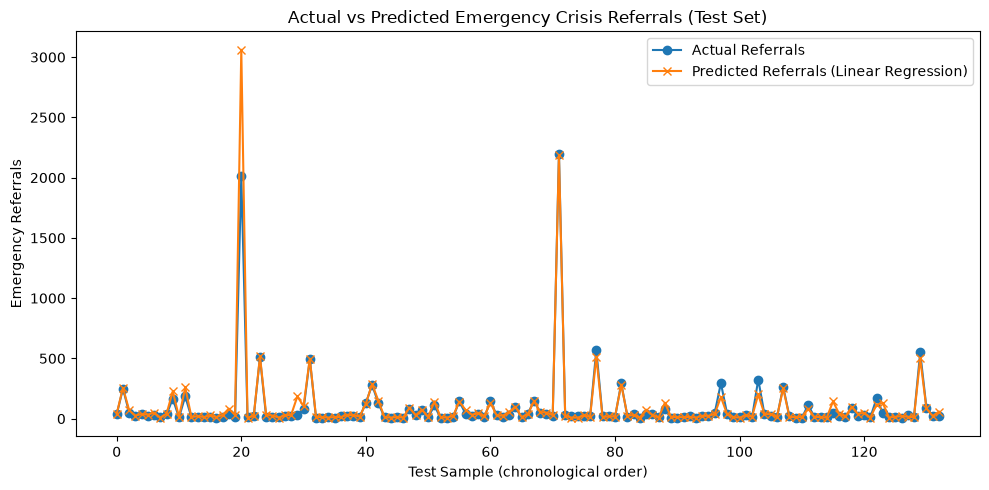

In [45]:
# ============================================================
# STEP 19: Visualize predicted vs actual values
# ============================================================
# A chart makes it much easier to see HOW WELL the model tracks 
# real referral patterns, compared to just looking at MAE/R² numbers.
# We plot the test set (data the model never saw during training) 
# so this is an honest, unbiased view of performance.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Referrals', marker='o')
plt.plot(y_pred, label='Predicted Referrals (Linear Regression)', marker='x')
plt.title('Actual vs Predicted Emergency Crisis Referrals (Test Set)')
plt.xlabel('Test Sample (chronological order)')
plt.ylabel('Emergency Referrals')
plt.legend()
plt.tight_layout()
plt.show()

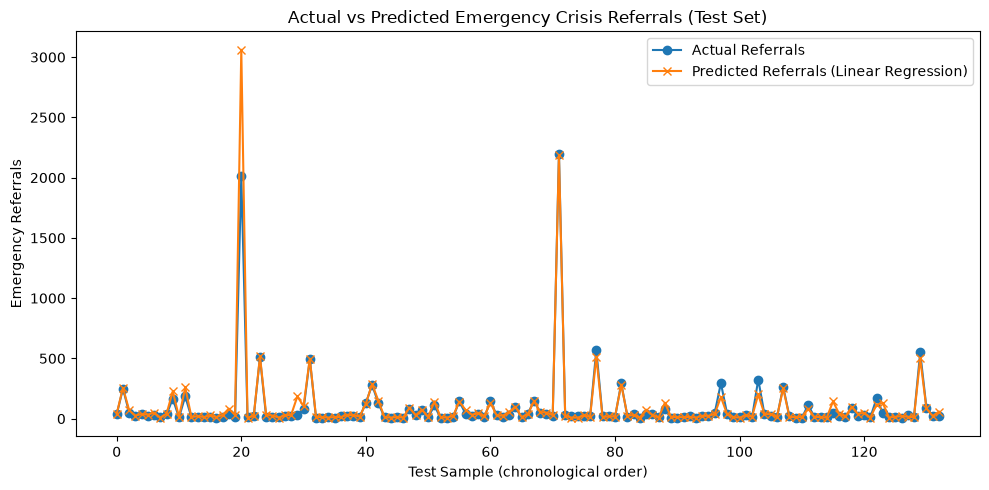

In [46]:
# ============================================================
# STEP 20: Save the chart as an image for the README/portfolio
# ============================================================
# Saving this as a PNG lets us embed it directly in the README, 
# so anyone viewing the GitHub repo can see the model's performance 
# at a glance, without needing to run the notebook themselves.

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Referrals', marker='o')
plt.plot(y_pred, label='Predicted Referrals (Linear Regression)', marker='x')
plt.title('Actual vs Predicted Emergency Crisis Referrals (Test Set)')
plt.xlabel('Test Sample (chronological order)')
plt.ylabel('Emergency Referrals')
plt.legend()
plt.tight_layout()

plt.savefig('../reports/actual_vs_predicted.png', dpi=150)
plt.show()

In [47]:
# ============================================================
# STEP 22: Identify the largest prediction errors
# ============================================================
# Understanding WHERE the model struggles most is just as valuable 
# as knowing its overall accuracy. This helps us be honest about 
# limitations, and can reveal patterns (e.g. does it struggle more 
# with very high-volume providers, or unusual one-off spikes?).

results_df = X_test.copy()
results_df['actual'] = y_test.values
results_df['predicted'] = y_pred
results_df['error'] = results_df['actual'] - results_df['predicted']
results_df['abs_error'] = results_df['error'].abs()

# Bring back the provider name and date for context
results_df['provider'] = df_model_clean.loc[X_test.index, 'PRIMARY_LEVEL_DESCRIPTION']
results_df['date'] = df_model_clean.loc[X_test.index, 'REPORTING_PERIOD_START']

# Show the 10 largest errors
worst_predictions = results_df.sort_values('abs_error', ascending=False).head(10)
worst_predictions[['provider', 'date', 'actual', 'predicted', 'error']]

MEASURE_NAME,provider,date,actual,predicted,error
129,England,2026-02-01,2013.0,3061.170472,-1048.170472
1176,UNKNOWN,2026-02-01,30.0,184.401719,-154.401719
35,BIRMINGHAM AND SOLIHULL MENTAL HEALTH NHS FOUN...,2026-03-01,325.0,200.991876,124.008124
268,NHS BIRMINGHAM AND SOLIHULL ICB - 15E,2026-03-01,295.0,180.191595,114.808405
106,EAST LONDON NHS FOUNDATION TRUST,2026-03-01,50.0,143.247287,-93.247287
772,NHS NORTH EAST LONDON ICB - A3A8R,2026-03-01,45.0,129.134026,-84.134026
34,BIRMINGHAM AND SOLIHULL MENTAL HEALTH NHS FOUN...,2026-02-01,185.0,259.437381,-74.437381
267,NHS BIRMINGHAM AND SOLIHULL ICB - 15E,2026-02-01,165.0,227.497739,-62.497739
161,KENT AND MEDWAY MENTAL HEALTH NHS TRUST,2026-03-01,570.0,514.567976,55.432024
118,ESSEX PARTNERSHIP UNIVERSITY NHS FOUNDATION TRUST,2026-03-01,170.0,116.830602,53.169398


In [48]:
# ============================================================
# STEP 23: Remove aggregate/non-provider rows (data cleaning fix)
# ============================================================
# "England" is a national-level total, not an individual provider — 
# it doesn't belong in a model trained on individual service patterns. 
# "UNKNOWN" is a placeholder for unidentified providers and should 
# also be excluded, since it doesn't represent a real, trackable service.

exclude_names = ['England', 'UNKNOWN']

df_model_clean = df_model_clean[~df_model_clean['PRIMARY_LEVEL_DESCRIPTION'].isin(exclude_names)].copy()

print(f"Rows after excluding aggregate/unknown entries: {len(df_model_clean)}")

# Rebuild X and y from the corrected data
X = df_model_clean[features]
y = df_model_clean[target]

# Redo the time-based split
df_model_clean = df_model_clean.sort_values('REPORTING_PERIOD_START')
split_index = int(len(df_model_clean) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Rows after excluding aggregate/unknown entries: 646
Training set: 516 rows
Test set: 130 rows


In [50]:
# ============================================================
# STEP 24: Re-test Random Forest on the cleaned data
# ============================================================
# Since removing "England" (an extreme outlier) improved Linear 
# Regression significantly, it's worth checking whether Random 
# Forest also performs better now — the earlier comparison may 
# have been unfairly affected by that same bad data.

rf_model_clean = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_clean.fit(X_train, y_train)

y_pred_rf_clean = rf_model_clean.predict(X_test)

mae_rf_clean = mean_absolute_error(y_test, y_pred_rf_clean)
r2_rf_clean = r2_score(y_test, y_pred_rf_clean)

print(f"Random Forest (cleaned data) - MAE: {mae_rf_clean:.2f}")
print(f"Random Forest (cleaned data) - R²: {r2_rf_clean:.3f}")
print(f"\nFor comparison, Linear Regression (cleaned data) - MAE: {mae:.2f}, R²: {r2:.3f}")

Random Forest (cleaned data) - MAE: 14.81
Random Forest (cleaned data) - R²: 0.899

For comparison, Linear Regression (cleaned data) - MAE: 13.51, R²: 0.946


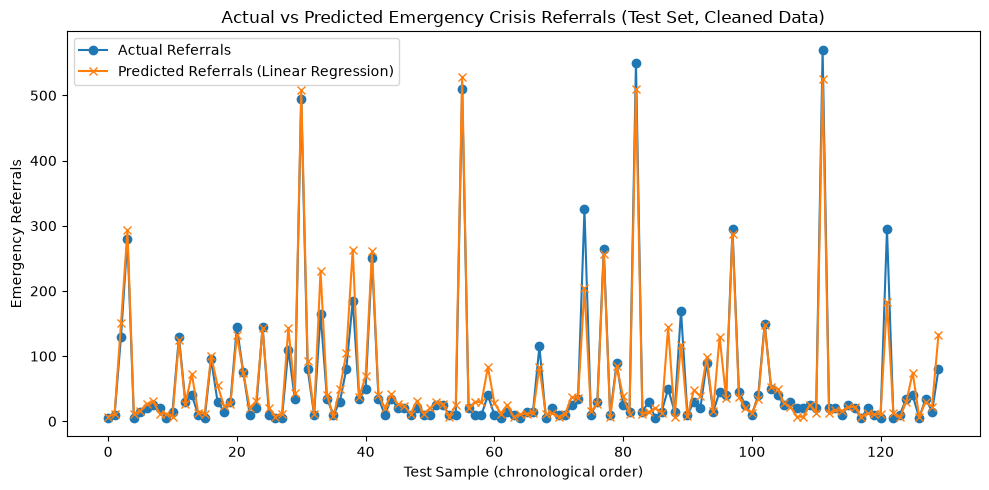

In [51]:
# ============================================================
# STEP 25: Regenerate visualization with cleaned data
# ============================================================
# This replaces our earlier chart, which included the distorted 
# "England" data point. This version reflects our final, corrected 
# model performance.

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Referrals', marker='o')
plt.plot(y_pred, label='Predicted Referrals (Linear Regression)', marker='x')
plt.title('Actual vs Predicted Emergency Crisis Referrals (Test Set, Cleaned Data)')
plt.xlabel('Test Sample (chronological order)')
plt.ylabel('Emergency Referrals')
plt.legend()
plt.tight_layout()

plt.savefig('../reports/actual_vs_predicted.png', dpi=150)
plt.show()